***Uploading DATASET***

In [338]:
import pandas as pd
import numpy as nm

In [339]:
df1=pd.read_csv("/content/Personal_Finance_Dataset.csv")

print(f"df1 shape:{df1.shape}")


df1 shape:(1500, 5)


In [340]:
df1.head()

,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


In [341]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1500 non-null   object 
 1   Transaction Description  1500 non-null   object 
 2   Category                 1500 non-null   object 
 3   Amount                   1500 non-null   float64
 4   Type                     1500 non-null   object 
dtypes: float64(1), object(4)
memory usage: 58.7+ KB


Cleaning the Dataset

In [342]:
#as we can see we dont have date in correct format
df1['Date']=pd.to_datetime(df1['Date'])

In [343]:
df1["Date"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1500 entries, 0 to 1499
Series name: Date
Non-Null Count  Dtype         
--------------  -----         
1500 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 11.8 KB


In [344]:
#Cleaning Text Columns
df1['Category'] = df1['Category'].str.lower().str.strip()
df1['Transaction Description'] = df1['Transaction Description'].str.lower().str.strip()
df1['Type'] = df1['Type'].str.lower().str.strip()

In [345]:
df1.head()

,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,score each.,food & drink,1485.69,expense
1,2020-01-02,quality throughout.,utilities,1475.58,expense
2,2020-01-04,instead ahead despite measure ago.,rent,1185.08,expense
3,2020-01-05,information last everything thank serve.,investment,2291.00,income
4,2020-01-13,future choice whatever from.,food & drink,1126.88,expense


In [346]:
#now we will make
df1['Month']=df1['Date'].dt.month
df1['year']=df1['Date'].dt.year
df1['Day_Name']=df1['Date'].dt.day_name()

In [347]:
df1.head()

,Date,Transaction Description,Category,Amount,Type,Month,year,Day_Name
0,2020-01-02,score each.,food & drink,1485.69,expense,1,2020,Thursday
1,2020-01-02,quality throughout.,utilities,1475.58,expense,1,2020,Thursday
2,2020-01-04,instead ahead despite measure ago.,rent,1185.08,expense,1,2020,Saturday
3,2020-01-05,information last everything thank serve.,investment,2291.00,income,1,2020,Sunday
4,2020-01-13,future choice whatever from.,food & drink,1126.88,expense,1,2020,Monday


In [348]:
df1.rename(columns={'Type': 'flow'}, inplace=True)

In [349]:
df1.drop_duplicates(inplace=True)

In [350]:
df1.value_counts(df1['flow'])

,count
flow,
expense,1222
income,278


So here we can see dataset shows significantly more expense transactions than income transactions arounf (1222/278=4.4x), which tells us frequent small spending behavior compared to fewer income events.

In [351]:
# lets check total expense and income
df1.groupby('flow')['Amount'].sum()

,Amount
flow,
expense,1227194.37
income,734087.00


#***EDA(Exploratory Data Analysis)***

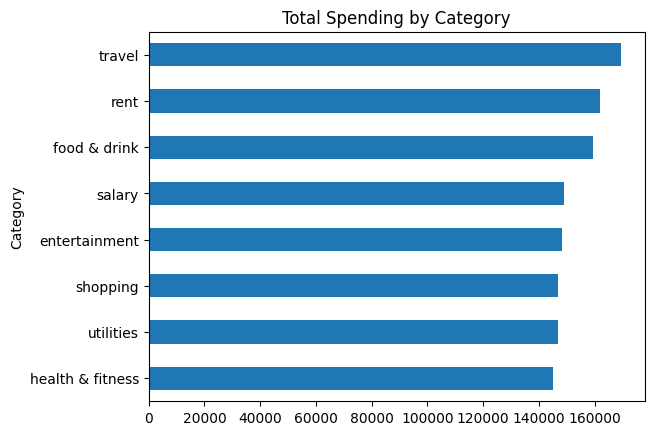

In [352]:
import matplotlib.pyplot as plt

df1[df1['flow'] == 'expense'].groupby('Category')['Amount'].sum().sort_values().plot(kind='barh')
plt.title("Total Spending by Category")
plt.show()

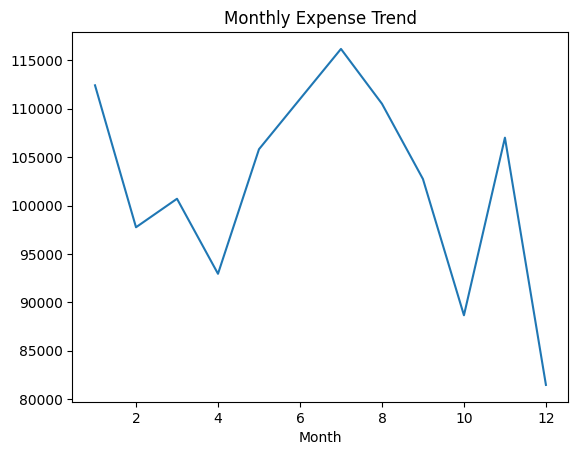

In [353]:
df1[df1['flow'] == 'expense'].groupby('Month')['Amount'].sum().plot()
plt.title("Monthly Expense Trend")
plt.show()

Monthly expenses show high variability with a peak in mid year and a sharp decline towards year-end, indicating inconsistent spending behavior and potential lack of structured budgeting

Step 1: Add Moving Average

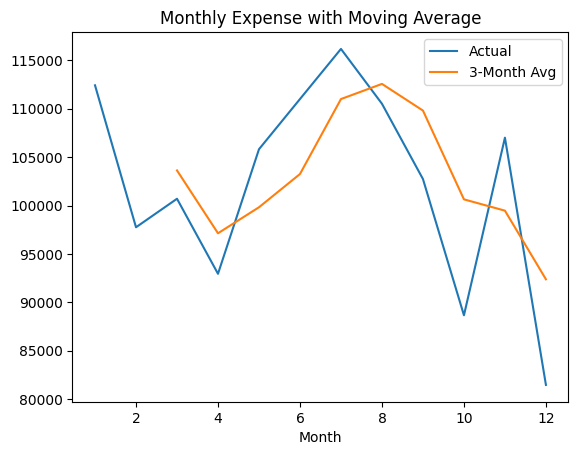

In [354]:
df1_monthly = df1[df1['flow'] == 'expense'].groupby('Month')['Amount'].sum()

df1_monthly_ma = df1_monthly.rolling(window=3).mean()

df1_monthly.plot(label='Actual')
df1_monthly_ma.plot(label='3-Month Avg')

plt.legend()
plt.title("Monthly Expense with Moving Average")
plt.show()

Step 2: Detect Anomalies

In [355]:
mean = df1_monthly.mean()
std = df1_monthly.std()

threshold_high = mean + 1.5*std
threshold_low = mean - 1.5*std

anomalies = df1_monthly[(df1_monthly > threshold_high) | (df1_monthly < threshold_low)]


In [356]:
anomalies

,Amount
Month,
12,81464.33


An anomaly detection model identified a significant drop in expenses in Month 12, suggesting a behavioral shift or potential external influence affecting spending patterns.

#***Model***

we have to predict How much will I spend next month and now for this lets have the expenses of each month

In [357]:
df1_monthly = df1[df1['flow'] == 'expense'].groupby('Month')['Amount'].sum().reset_index()

In [358]:
df1_monthly

,Month,Amount
0,1,112418.85
1,2,97753.66
2,3,100698.45
3,4,92945.59
4,5,105815.39
5,6,111000.97
6,7,116178.50
7,8,110513.11
8,9,102735.49
9,10,88660.28


In [359]:
#model training
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score

X = df_monthly[['Month']]
y = df_monthly['Amount']


In [360]:

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [364]:
next_month = [[13]]  # next month after 12
prediction = model.predict(next_month)

print(f"Predicted Expense for Next Month:{prediction[0]}")

Predicted Expense for Next Month:96056.15409090911


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Visualizing Prediction

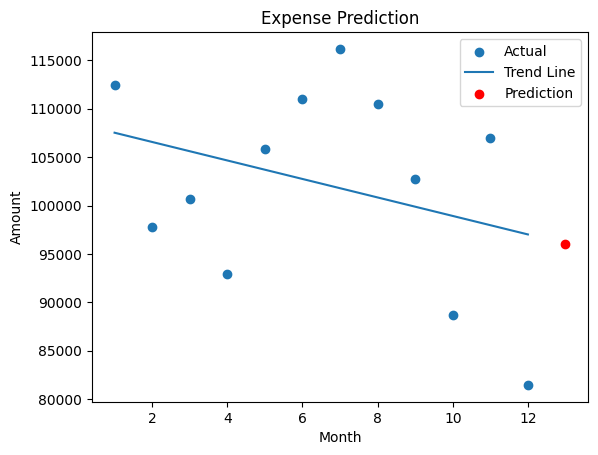

In [365]:
import matplotlib.pyplot as plt

plt.scatter(X, y, label='Actual')
plt.plot(X, model.predict(X), label='Trend Line')

plt.scatter(13, prediction, color='red', label='Prediction')

plt.xlabel("Month")
plt.ylabel("Amount")
plt.title("Expense Prediction")
plt.legend()
plt.show()

I used a regression model to analyze historical monthly expenses and forecast future spending trends.
but
Since the dataset is small and linear regression assumes a linear trend, predictions are approximate and can be improved using time series models or increaing the data based on years